## Performing Linear Regression (Manually)


In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv(r'/home/gaurav/MachineLearning2026_Gaurav/Dataset/medical.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
non_smokers = df[df['smoker'] == 'no']

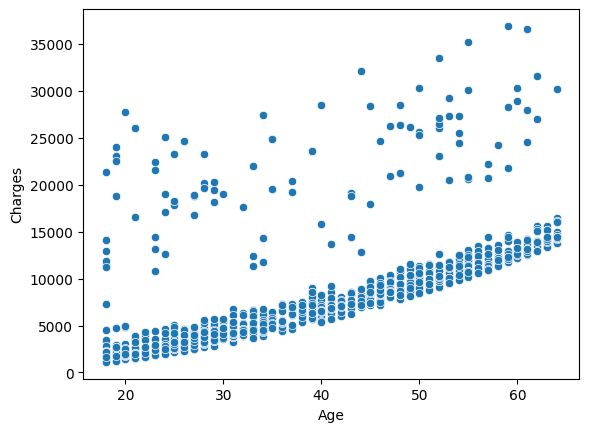

In [13]:

sns.scatterplot(x='age', y='charges', data=non_smokers)
plt.xlabel('Age')   
plt.ylabel('Charges')
plt.show()

### performing  simple linaear regression manually 

Hit and Trial

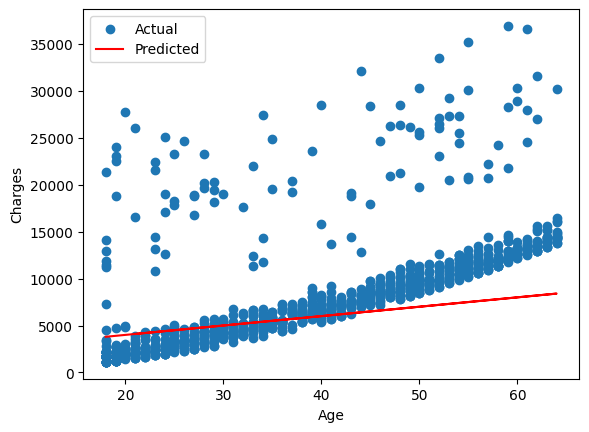

In [14]:
w = 100
b = 2000
y_pred = w * non_smokers['age'] + b
plt.scatter(non_smokers['age'], non_smokers['charges'], label='Actual')
plt.plot(non_smokers['age'], y_pred, color='red', label='Predicted')
plt.xlabel('Age')       
plt.ylabel('Charges')
plt.legend()
plt.show()

Finding Best fit 

In [15]:
def predict_error(targets , predictions):
    error = targets - predictions
    rmse = np.sqrt(np.mean(error ** 2))
    return rmse
    

slope (w) = 267.2489
intercept (b) = -2091.42
RMSE = 4662.51


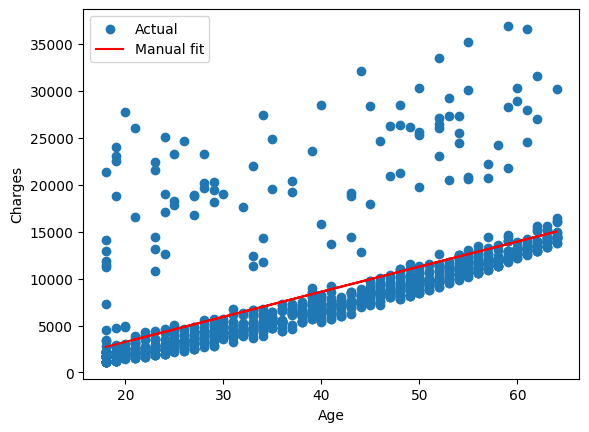

In [16]:
# prepare arrays
x = non_smokers['age'].values
y = non_smokers['charges'].values

# compute means
x_mean = np.mean(x)
y_mean = np.mean(y)

# compute slope (w) and intercept (b)
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
w_manual = numerator / denominator
b_manual = y_mean - w_manual * x_mean

print(f"slope (w) = {w_manual:.4f}")
print(f"intercept (b) = {b_manual:.2f}")

# predictions and rmse
pred_manual = w_manual * x + b_manual
rmse_manual = predict_error(y, pred_manual)
print(f"RMSE = {rmse_manual:.2f}")

# plot results
plt.scatter(x, y, label='Actual')
plt.plot(x, pred_manual, color='red', label='Manual fit')
plt.xlabel('Age'); plt.ylabel('Charges');
plt.legend();
plt.show()